# Dashboard Prototype

This notebook designs the dashboard structure for the AI-driven Auckland public transport decision-support system.

The dashboard prototype integrates:
- delay prediction results,
- model evaluation summaries,
- SHAP explainability insights,
- decision-engine recommendations,
- and SUMO scenario validation outputs.

This notebook prepares the layout and visual logic that will later be converted into a Streamlit dashboard application.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
#load processed outputs
PROJECT_ROOT = Path.cwd().parent

decision_path = PROJECT_ROOT / "data" / "processed" / "decision_engine_output.csv"
sumo_scenarios_path = PROJECT_ROOT / "data" / "processed" / "sumo_scenarios.csv"
sumo_kpis_path = PROJECT_ROOT / "data" / "processed" / "sumo_kpis.csv"
sumo_validation_path = PROJECT_ROOT / "data" / "processed" / "sumo_validation_results.csv"

decision_df = pd.read_csv(decision_path)
sumo_scenarios = pd.read_csv(sumo_scenarios_path)
sumo_kpis = pd.read_csv(sumo_kpis_path)
sumo_validation = pd.read_csv(sumo_validation_path)

print("Decision output:", decision_df.shape)
print("SUMO scenarios:", sumo_scenarios.shape)
print("SUMO KPIs:", sumo_kpis.shape)
print("SUMO validation:", sumo_validation.shape)

Decision output: (2000, 7)
SUMO scenarios: (3, 6)
SUMO KPIs: (6, 4)
SUMO validation: (3, 8)


In [3]:
#Dashboard KPIs
total_records = len(decision_df)
avg_delay = decision_df["actual_arrival_delay_min"].mean()
high_risk_count = decision_df[decision_df["delay_risk"].isin(["High", "Severe"])].shape[0]
most_common_action = decision_df["recommended_action"].mode()[0]

dashboard_kpis = pd.DataFrame({
    "KPI": [
        "Total Records",
        "Average Delay (min)",
        "High/Severe Risk Cases",
        "Most Common Recommendation"
    ],
    "Value": [
        total_records,
        round(avg_delay, 2),
        high_risk_count,
        most_common_action
    ]
})

dashboard_kpis

,KPI,Value
0,Total Records,2000
1,Average Delay (min),13.32
2,High/Severe Risk Cases,863
3,Most Common Recommendation,Monitor route conditions


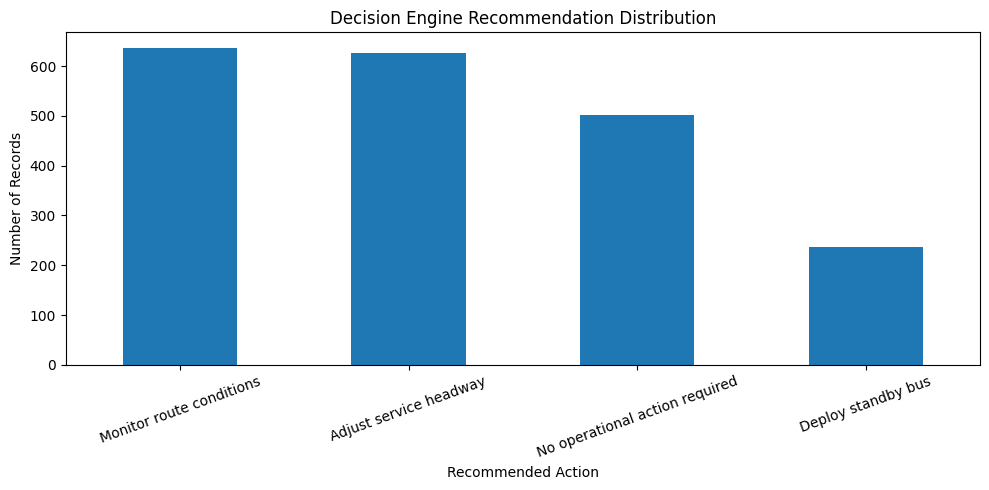

In [4]:
plt.figure(figsize=(10, 5))

decision_df["recommended_action"].value_counts().plot(kind="bar")

plt.title("Decision Engine Recommendation Distribution")
plt.xlabel("Recommended Action")
plt.ylabel("Number of Records")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

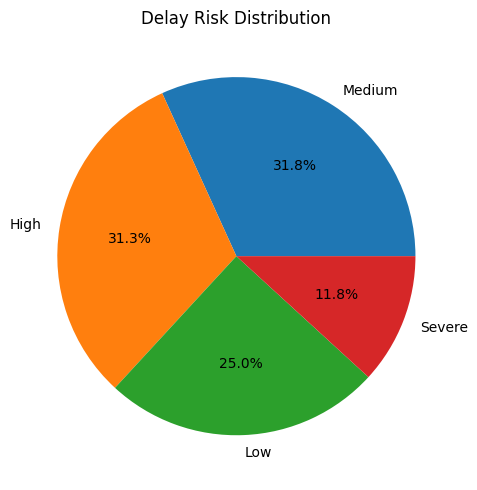

In [5]:
plt.figure(figsize=(8, 5))

decision_df["delay_risk"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Delay Risk Distribution")
plt.ylabel("")
plt.tight_layout()
plt.show()

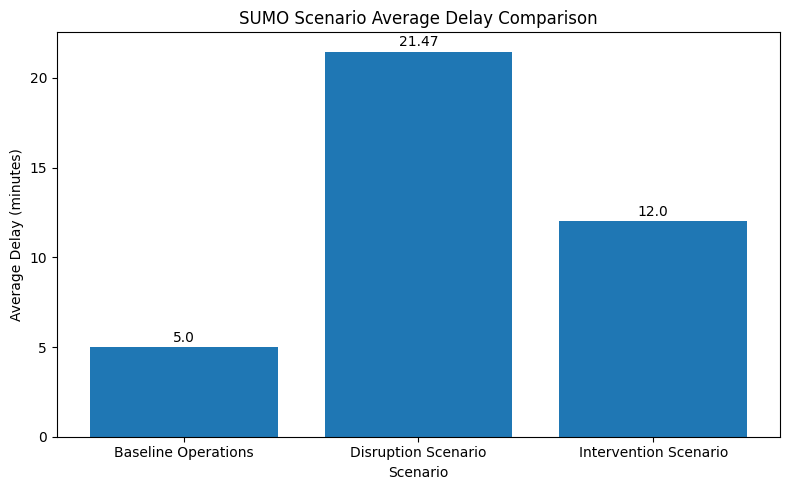

In [6]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    sumo_validation["scenario_name"],
    sumo_validation["avg_delay_min"]
)

plt.title("SUMO Scenario Average Delay Comparison")
plt.xlabel("Scenario")
plt.ylabel("Average Delay (minutes)")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.3,
        round(height, 2),
        ha='center'
    )

plt.tight_layout()
plt.show()

In [7]:
operational_insights = [
    "Most delays are concentrated in medium and high-risk operational categories.",
    "AI recommendations frequently suggest route monitoring and headway adjustment.",
    "SUMO intervention scenarios demonstrate potential delay reduction compared to disruption scenarios.",
    "High congestion levels correlate with increased operational intervention recommendations.",
    "The integrated framework demonstrates feasibility for intelligent transport decision support."
]

for idx, insight in enumerate(operational_insights, start=1):
    print(f"{idx}. {insight}")

1. Most delays are concentrated in medium and high-risk operational categories.
2. AI recommendations frequently suggest route monitoring and headway adjustment.
3. SUMO intervention scenarios demonstrate potential delay reduction compared to disruption scenarios.
4. High congestion levels correlate with increased operational intervention recommendations.
5. The integrated framework demonstrates feasibility for intelligent transport decision support.


# Dashboard Prototype Summary

The Streamlit dashboard will integrate:

- AI delay predictions
- Weather-aware transport monitoring
- SHAP explainability outputs
- Decision-support recommendations
- SUMO validation scenarios
- Operational insights for transport operators

This dashboard serves as the final integrated presentation layer of the capstone project.